In [7]:
import pandas as pd
import numpy as np
import os

def filter_and_undersample(
    resmat: pd.DataFrame, 
    min_threshold: int, 
    max_nan_percent: float = 0.1,
    groups: list = None,
    output_dir: str = "data"
) -> pd.DataFrame:
    """
    Filters, undersamples (with group-awareness), and then filters rows by a NaN threshold.

    Args:
        resmat (pd.DataFrame): The original, imbalanced response matrix.
        min_threshold (int): The minimum number of items a scenario must have.
        max_nan_percent (float): The maximum allowed percentage of NaN values in a row. 
                                 Rows exceeding this are dropped. Defaults to 0.1 (10%).
        groups (list, optional): A list of lists, where each inner list contains names of 
                                 scenarios to be treated as a single pool for undersampling. 
                                 Defaults to None.
        output_dir (str): The directory where the output file will be saved.

    Returns:
        pd.DataFrame: A new DataFrame that is balanced and filtered by the NaN threshold.
    """
    print("--- Starting Filtering and Undersampling Process ---")
    if groups is None:
        groups = []
    
    # 1. & 2. Filter scenarios by size
    scenario_labels = resmat.columns.get_level_values('scenario')
    scenario_counts = scenario_labels.value_counts()
    scenarios_to_process = scenario_counts[scenario_counts >= min_threshold]
    
    if len(scenarios_to_process) < 2:
        print(f"Warning: Less than two scenarios meet the threshold. Cannot create a balanced dataset.")
        return pd.DataFrame()
        
    print(f"Kept {len(scenarios_to_process)} scenarios with at least {min_threshold} items.")
    
    # 3. Find the new minimum size for undersampling
    target_sample_size = scenarios_to_process.min()
    print(f"All kept scenarios/groups will be undersampled to {target_sample_size} items.")

    # 4. Loop through filtered scenarios and sample non-empty columns
    balanced_cols = []
    processed_scenarios = set()
    np.random.seed(42)  # for reproducibility
    
    print("\n--- Processing Groups for Undersampling ---")
    for group in groups:
        members_in_resmat = [s for s in group if s in scenarios_to_process.index]
        if not members_in_resmat:
            continue

        # --- EDIT: Generate the mended group name ---
        group_name = '_'.join([s[:3] for s in members_in_resmat])
        print(f"Processing group '{group_name}': {members_in_resmat}")
        # --- END OF EDIT ---
        
        group_pool_indices = []
        for member in members_in_resmat:
            member_indices = np.where(scenario_labels == member)[0]
            cols_for_member = resmat.iloc[:, member_indices]
            non_nan_mask = cols_for_member.notna().any(axis=0)
            valid_indices = member_indices[non_nan_mask.values]
            group_pool_indices.extend(valid_indices)
        
        if len(group_pool_indices) < target_sample_size:
            # --- EDIT: Use the new group name in the warning message ---
            print(f"⚠️ Warning: Group '{group_name}' will be skipped (combined pool of {len(group_pool_indices)} is less than target {target_sample_size}).")
            # --- END OF EDIT ---
            processed_scenarios.update(members_in_resmat)
            continue
            
        sampled_indices = np.random.choice(
            group_pool_indices, size=target_sample_size, replace=False
        )
        balanced_cols.extend(sampled_indices)
        processed_scenarios.update(members_in_resmat)
        print(f"-> Sampled {len(sampled_indices)} items from the combined pool.")
        
    # Process remaining singleton scenarios
    print("\n--- Processing Singleton Scenarios ---")
    for scenario in scenarios_to_process.index:
        if scenario in processed_scenarios:
            continue

        scenario_col_indices = np.where(scenario_labels == scenario)[0]
        cols_for_scenario = resmat.iloc[:, scenario_col_indices]
        non_nan_mask = cols_for_scenario.notna().any(axis=0)
        valid_indices_for_sampling = scenario_col_indices[non_nan_mask.values]
        
        if len(valid_indices_for_sampling) < target_sample_size:
            print(f"⚠️ Warning: Scenario '{scenario}' will be skipped (not enough non-empty columns).")
            continue
        
        sampled_indices = np.random.choice(
            valid_indices_for_sampling, size=target_sample_size, replace=False
        )
        balanced_cols.extend(sampled_indices)
        print(f"Processed '{scenario}': Sampled {len(sampled_indices)} items.")


    if not balanced_cols:
        print("❌ Error: No scenarios or groups could be sampled.")
        return pd.DataFrame()

    # 5. Create the new, balanced DataFrame
    resmat_balanced = resmat.iloc[:, sorted(balanced_cols)]
    print(f"\nShape after balancing columns: {resmat_balanced.shape}")
    
    # 6. Filter rows by NaN threshold
    print(f"--- Filtering rows by NaN threshold ({max_nan_percent:.0%}) ---")
    rows_before_filter = resmat_balanced.shape[0]
    total_cols = resmat_balanced.shape[1]
    min_valid_values = int(total_cols * (1 - max_nan_percent))
    print(f"A model (row) must have at least {min_valid_values} valid responses (out of {total_cols}) to be kept.")
    resmat_filtered = resmat_balanced.dropna(axis=0, thresh=min_valid_values)
    rows_after_filter = resmat_filtered.shape[0]
    print(f"Removed {rows_before_filter - rows_after_filter} models that did not meet the threshold.")

    if resmat_filtered.empty:
        print("❌ CRITICAL: After filtering, the DataFrame is empty.")
        return resmat_filtered
    
    resmat_final = resmat_filtered
    print(f"Final matrix shape: {resmat_final.shape}")
    
    print("\n--- Post-Processing Scenario Counts ---")
    final_scenario_counts = resmat_final.columns.get_level_values('scenario').value_counts()
    print(final_scenario_counts)
    print("----------------------------------------")
    
    # Verify calibration condition
    final_rows_check = (resmat_final.notna().sum(axis=1) > 0).all()
    final_cols_check = (resmat_final.notna().sum(axis=0) > 0).all()
    calibration_valid = final_rows_check and final_cols_check
    print(f"Calibration condition check: {'✅ PASS' if calibration_valid else '❌ FAIL'}")
    
    # 7. Save the new DataFrame to a pickle file
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    output_filename = f"resmat_{min_threshold}.pkl"
    full_path = os.path.join(output_dir, output_filename)
    resmat_final.to_pickle(full_path)
    print(f"Saved filtered DataFrame to: '{full_path}'")
    
    print("--------------------------------------------------")
    
    return resmat_final

In [8]:

# Define the benchmark groups as discussed
REDUNDANT_BENCHMARK_GROUPS = [
    ['legalbench', 'legal_support', 'lsat_qa'],
    ['math', 'gsm'],
    ['synthetic_reasoning', 'dyck_language_np=3'],
    ['entity_matching', 'entity_data_imputation'],
    ['mmlu', 'air_bench_2024']
]

# --- Step 1: Load Data and Print Original Counts ---
print("Loading response matrix...")
resmat = pd.read_pickle("../data/resmat.pkl")

print("\n--- Original Scenario Counts ---")
scenario_counts = resmat.columns.get_level_values('scenario').value_counts()
print(scenario_counts)
print("--------------------------------")

# --- Step 2: Perform Filtering and Undersampling ---
# Use the new function, passing the REDUNDANT_BENCHMARK_GROUPS list.
resmat_balanced = filter_and_undersample(
    resmat, 
    min_threshold=500, 
    max_nan_percent=1, 
    groups=REDUNDANT_BENCHMARK_GROUPS, # Pass the groups here
    output_dir="../data"
)

if resmat_balanced.empty:
    raise ValueError("Undersampling resulted in an empty DataFrame. Try a smaller min_threshold.")

Loading response matrix...

--- Original Scenario Counts ---
scenario
civil_comments                 29407
mmlu                           13223
wikifact                        5511
air_bench_2024                  4985
imdb                            3530
babi_qa                         3461
boolq                           3316
synthetic_reasoning             2234
legalbench                      1997
truthful_qa                     1888
entity_matching                 1396
raft                            1336
bbq                              999
med_qa                           998
gsm                              997
legal_support                    594
thai_exam                        557
dyck_language_np=3               500
commonsense                      498
lsat_qa                          454
math                             436
entity_data_imputation           395
ice                                0
synthetic_efficiency               0
blimp                              0
twitt

# Dimensional Reduction, train on fixed k

In [9]:
import pandas as pd
import sys
import numpy as np
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta_z_scores_numpy, a_for_z_numpy, b_for_z_numpy = load_and_rotate()

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores_numpy
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta_z_scores_numpy.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

/Users/ronan/Developer/reeval-multi/mirt-official/load_params.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.dev

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


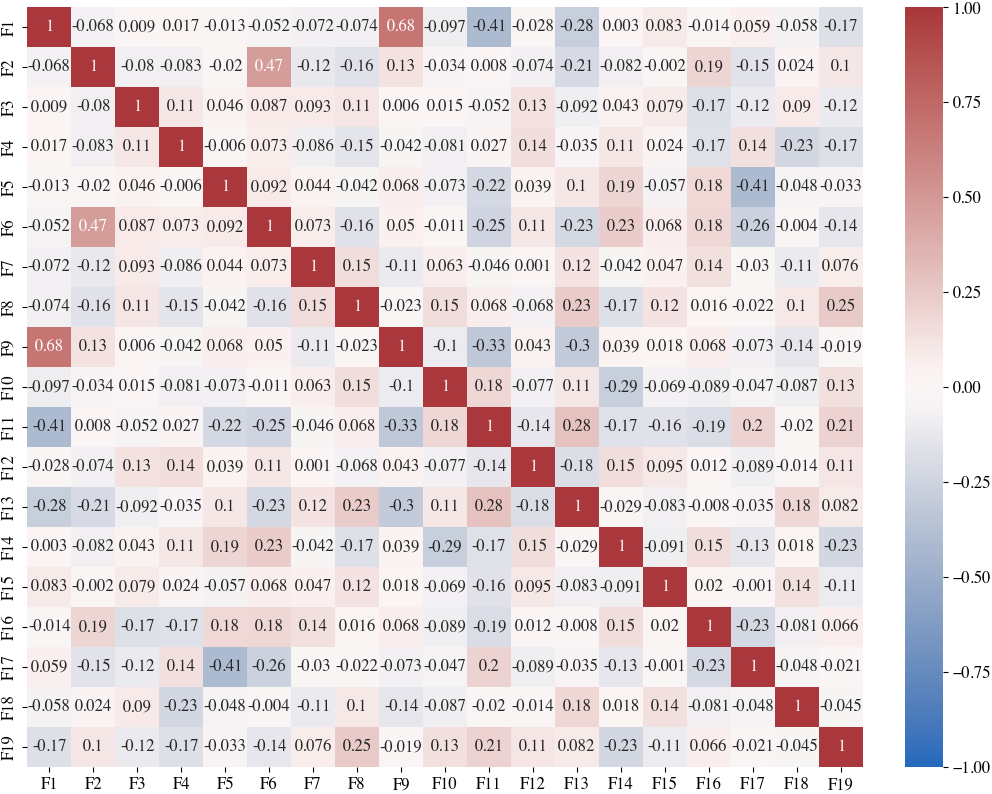

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# Assume 'ability_df' is your DataFrame of model abilities from the previous step
# It should have a shape of (n_models, k_factors)

# Calculate the correlation between the ability factors
factor_correlations = ability_df.corr(method='spearman').round(3)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(factor_correlations, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.savefig("../result/factor-correlations.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1724/2855997153.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1724/2855997153.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()


Created aggregated scenario scores DataFrame with shape: (183, 40)

Dropped 0 scenarios with zero variance: []
Kept 6 scenarios for correlation analysis.


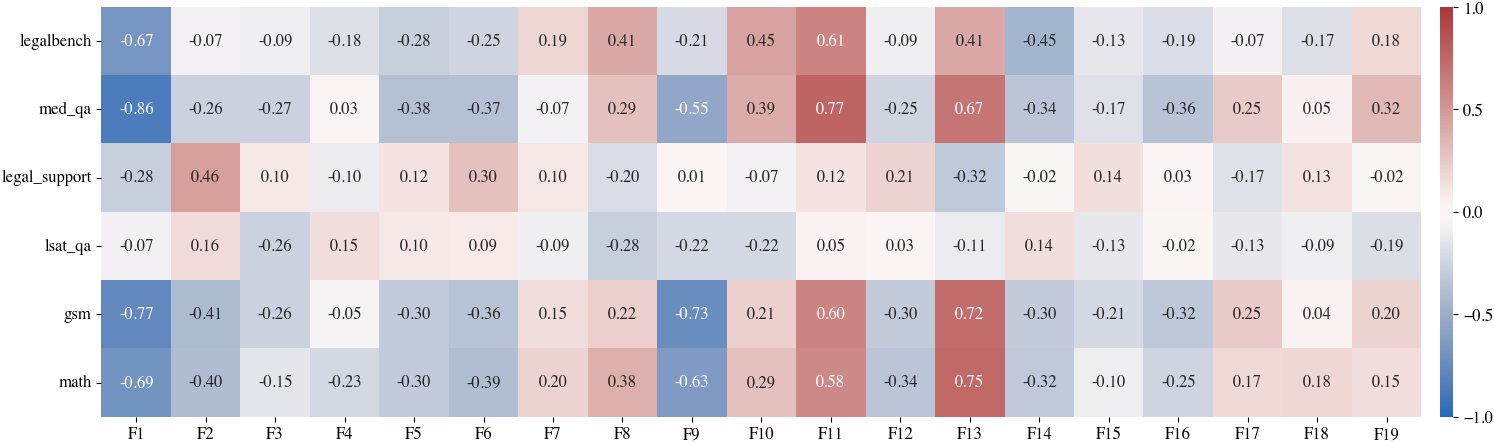

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step A: Aggregate resmat to get per-scenario scores ---
resmat = pd.read_pickle("../data/resmat.pkl")
resmat = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa'])]]
scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
print(f"Created aggregated scenario scores DataFrame with shape: {scenario_scores.shape}")

# --- NEW: Step B: Identify and filter out zero-variance scenarios ---
# Calculate the standard deviation of each scenario's scores
std_devs = scenario_scores.std()

# Find the scenarios where the scores actually vary (std > 0)
scenarios_to_keep = std_devs[std_devs > 0].index
scenarios_dropped = std_devs[std_devs == 0].index

# Create a new DataFrame with only the valid scenarios
scenario_scores_filtered = scenario_scores[scenarios_to_keep]

print(f"\nDropped {len(scenarios_dropped)} scenarios with zero variance: {list(scenarios_dropped)}")
print(f"Kept {len(scenarios_to_keep)} scenarios for correlation analysis.")

# --- Step C: Combine ability scores and the FILTERED scenario scores ---
combined_df = pd.concat([ability_df, scenario_scores_filtered], axis=1)


# --- Step D: Calculate the full correlation matrix ---
full_correlations = combined_df.corr(method='spearman')


# --- Step E: Isolate and visualize the part we care about ---
# We now use the filtered list of columns
factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

# --- Step E: Isolate and visualize with adjusted spacing ---

# 1. Create the figure and axes.
#    Add 'wspace' to control the horizontal gap between the heatmap and color bar.
fig, (ax_heatmap, ax_cbar) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4.5),
    gridspec_kw={
        'width_ratios': [100, 1],
        'wspace': 0.025
    }
)

ax_cbar.set_yticks(np.arange(-1, 1.1, 0.5))
factor_scenario_corr = factor_scenario_corr[[ 'legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']]
# 2. Draw the heatmap and color bar (same as before)
sns.heatmap(
    factor_scenario_corr.T,
    annot=True,
    cmap='vlag',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_ax=ax_cbar,
    cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}
)

# 3. Set labels (same as before)
ax_heatmap.set_ylabel('')
ax_heatmap.set_xlabel('')

# 4. Save and show the plot
plt.savefig("../result/factor-scenario-correlations.pdf", bbox_inches='tight')
plt.show()

Creating discrimination factors DataFrame...
Created discrimination factors DataFrame with shape: (78712, 19)
Created aggregated scenario discrimination DataFrame with shape: (40, 19)
Filtered to 6 scenarios for analysis

Using mean discrimination factors for each scenario:
scenario_discrimination_filtered shape: (6, 19)
                  F1     F2     F3     F4     F5     F6     F7     F8     F9  \
scenario                                                                       
gsm           -0.851 -0.108 -0.006 -0.016 -0.009 -0.177  0.051 -0.014 -0.729   
legal_support -0.133  0.073 -0.036 -0.050 -0.002  0.043  0.055 -0.012  0.059   
legalbench    -0.231  0.064 -0.022 -0.019 -0.077  0.004  0.025  0.039  0.028   
lsat_qa        0.118  0.075 -0.031 -0.041 -0.005  0.058  0.014 -0.010 -0.535   
math          -0.580 -0.106  0.022 -0.110 -0.051 -0.234  0.087  0.070 -0.693   
med_qa        -0.556  0.029 -0.018  0.022 -0.124 -0.115 -0.023  0.020 -0.224   

                 F10    F11    F12  

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1724/386033257.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


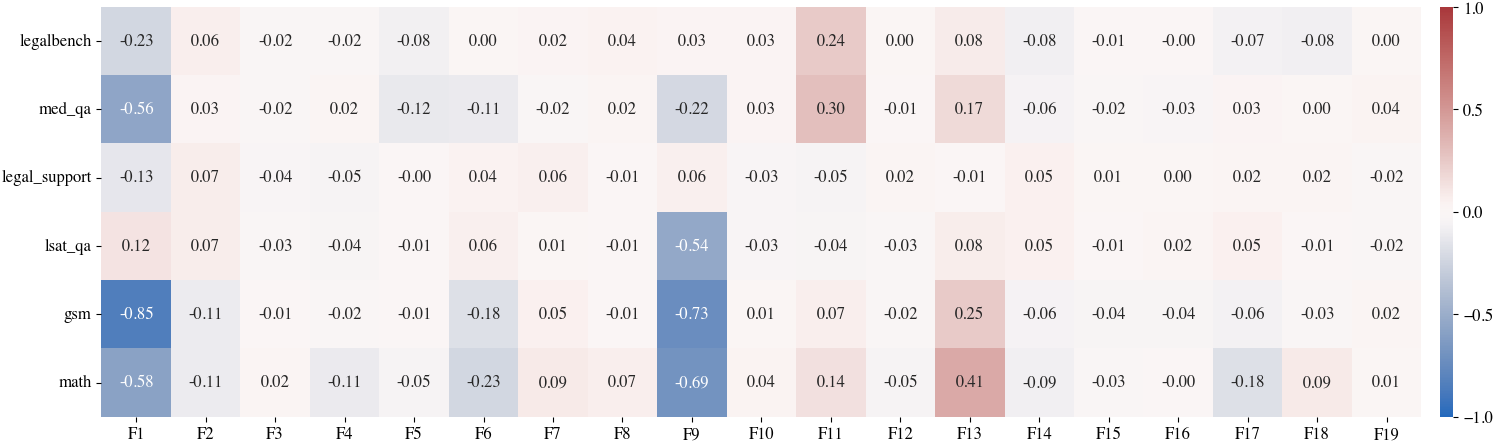


--- Analysis Complete ---
This plot shows mean discrimination factor values for each scenario
- Each cell shows the average discrimination value for that factor in that scenario's items
- Red values = items strongly discriminate on this factor
- Blue values = items weakly discriminate on this factor
- This reveals which cognitive factors are most emphasized in each scenario's items


In [21]:
# EDIT HERE - Correlation plot using discrimination factors (a parameters) instead of ability factors

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Step A: Create a dataframe for discrimination factors (a parameters) ---
# a_for_z_numpy has shape (n_items, k_factors) where n_items = 78712 and k_factors = 19
# We need to map each item to its scenario using resmat column structure

print("Creating discrimination factors DataFrame...")
resmat_full = pd.read_pickle("../data/resmat.pkl")

# Get the item names (column index) and their corresponding scenarios
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

# Create DataFrame with discrimination factors
# Each row represents an item, each column represents a factor
discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

print(f"Created discrimination factors DataFrame with shape: {discrimination_df.shape}")

# --- Step B: Aggregate discrimination factors by scenario ---
# Group by scenario and take the mean of discrimination factors for each scenario
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()
print(f"Created aggregated scenario discrimination DataFrame with shape: {scenario_discrimination.shape}")

# --- Step C: Filter to only include the same scenarios as before ---
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"Filtered to {len(scenario_discrimination_filtered)} scenarios for analysis")

# --- Step D: Use the mean discrimination factors directly ---
# No need for correlation - just show the mean F values for each scenario

print("\nUsing mean discrimination factors for each scenario:")
print(f"scenario_discrimination_filtered shape: {scenario_discrimination_filtered.shape}")
print(scenario_discrimination_filtered.round(3))

# Transpose to match the original plot format (scenarios as rows, factors as columns)
discrimination_matrix = scenario_discrimination_filtered

# --- Step E: Create the visualization ---
fig, (ax_heatmap, ax_cbar) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4.5),
    gridspec_kw={
        'width_ratios': [100, 1],
        'wspace': 0.025
    }
)

# Reorder rows to match the previous plot
scenario_order = ['legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']
discrimination_matrix_ordered = discrimination_matrix.reindex(scenario_order)

# Create the heatmap
sns.heatmap(
    discrimination_matrix_ordered,
    annot=True,
    cmap='vlag',
    vmin=-1,
    vmax=1,
    center=0,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_ax=ax_cbar,
    cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}
)

# Set labels
ax_heatmap.set_ylabel('')
ax_heatmap.set_xlabel('')

# Save and show the plot
plt.savefig("../result/discrimination-factor-means-by-scenario.pdf", bbox_inches='tight')
plt.show()

print("\n--- Analysis Complete ---")
print("This plot shows mean discrimination factor values for each scenario")
print("- Each cell shows the average discrimination value for that factor in that scenario's items")
print("- Red values = items strongly discriminate on this factor")
print("- Blue values = items weakly discriminate on this factor") 
print("- This reveals which cognitive factors are most emphasized in each scenario's items")

In [14]:
# Debug cell - Let's check what's happening step by step

# First, let's check if we have the right variables available
print("Available variables check:")
print(f"a_for_z_numpy shape: {a_for_z_numpy.shape}")
print(f"scenario_scores_filtered available: {'scenario_scores_filtered' in locals()}")

# If scenario_scores_filtered is not available, let's recreate it
if 'scenario_scores_filtered' not in locals():
    print("Recreating scenario_scores_filtered...")
    # Step A: Aggregate resmat to get per-scenario scores
    resmat = pd.read_pickle("../data/resmat.pkl")
    resmat = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa'])]]
    scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
    
    # Step B: Filter out zero-variance scenarios
    std_devs = scenario_scores.std()
    scenarios_to_keep = std_devs[std_devs > 0].index
    scenario_scores_filtered = scenario_scores[scenarios_to_keep]
    print(f"Recreated scenario_scores_filtered with shape: {scenario_scores_filtered.shape}")

print("\nNow let's check the discrimination factors:")
resmat_full = pd.read_pickle("../data/resmat.pkl")
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

# Create discrimination DataFrame
discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

print(f"discrimination_df shape: {discrimination_df.shape}")

# Group by scenario and take mean
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()
print(f"scenario_discrimination shape: {scenario_discrimination.shape}")
print("Available scenarios in discrimination data:")
print(scenario_discrimination.index.tolist())

# Filter to match our target scenarios
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"\nFiltered discrimination data shape: {scenario_discrimination_filtered.shape}")
print("Scenarios in filtered discrimination data:")
print(scenario_discrimination_filtered.index.tolist())
print("Scenarios in filtered scores data:")
print(scenario_scores_filtered.index.tolist())

# Check for data alignment issues
print("\nSample discrimination values (first 3 factors, first 3 scenarios):")
print(scenario_discrimination_filtered.iloc[:3, :3])

print("\nSample scenario scores (first 3 scenarios):")
print(scenario_scores_filtered.iloc[:3])


Available variables check:
a_for_z_numpy shape: (78712, 19)
scenario_scores_filtered available: True

Now let's check the discrimination factors:
discrimination_df shape: (78712, 19)
scenario_discrimination shape: (40, 19)
Available scenarios in discrimination data:
['air_bench_2024', 'babi_qa', 'bbq', 'blimp', 'bold', 'boolq', 'civil_comments', 'code', 'commonsense', 'copyright', 'disinfo', 'dyck_language_np=3', 'entity_data_imputation', 'entity_matching', 'gsm', 'ice', 'imdb', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa', 'mmlu', 'msmarco', 'narrative_qa', 'natural_qa', 'quac', 'raft', 'real_toxicity_prompts', 'summarization_cnndm', 'summarization_xsum', 'synthetic_efficiency', 'synthetic_reasoning', 'synthetic_reasoning_natural', 'thai_exam', 'the_pile', 'truthful_qa', 'twitter_aae', 'wikifact', 'wmt_14']

Filtered discrimination data shape: (6, 19)
Scenarios in filtered discrimination data:
['gsm', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa']
Scenarios 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1724/2291025550.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


=== Alternative Approach: Discrimination Factor Profiles by Scenario ===


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_1724/3906600148.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


Discrimination profiles shape: (6, 19)

Sample discrimination profiles:
                  F1     F2     F3     F4     F5     F6     F7     F8     F9  \
scenario                                                                       
legalbench    -0.231  0.064 -0.022 -0.019 -0.077  0.004  0.025  0.039  0.028   
med_qa        -0.556  0.029 -0.018  0.022 -0.124 -0.115 -0.023  0.020 -0.224   
legal_support -0.133  0.073 -0.036 -0.050 -0.002  0.043  0.055 -0.012  0.059   
lsat_qa        0.118  0.075 -0.031 -0.041 -0.005  0.058  0.014 -0.010 -0.535   
gsm           -0.851 -0.108 -0.006 -0.016 -0.009 -0.177  0.051 -0.014 -0.729   
math          -0.580 -0.106  0.022 -0.110 -0.051 -0.234  0.087  0.070 -0.693   

                 F10    F11    F12    F13    F14    F15    F16    F17    F18  \
scenario                                                                       
legalbench     0.028  0.244  0.000  0.084 -0.079 -0.015 -0.001 -0.067 -0.082   
med_qa         0.027  0.301 -0.010  0.165 -0.06

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

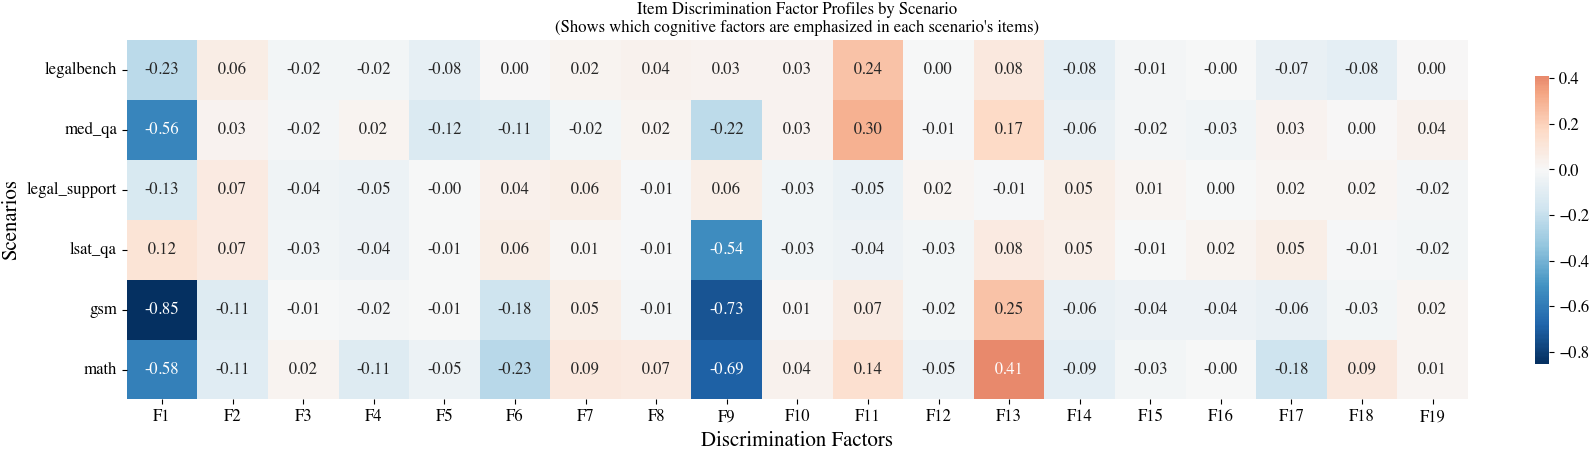

In [13]:
# ALTERNATIVE APPROACH: Compare discrimination factor patterns across scenarios
# This shows which cognitive factors (as measured by item discrimination) are emphasized in each scenario

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("=== Alternative Approach: Discrimination Factor Profiles by Scenario ===")

# Create the discrimination factors DataFrame (same as before)
resmat_full = pd.read_pickle("../data/resmat.pkl")
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

# Aggregate by scenario (mean discrimination factors per scenario)
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()

# Filter to our scenarios of interest
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"Discrimination profiles shape: {scenario_discrimination_filtered.shape}")

# Reorder scenarios to match previous plots
scenario_order = ['legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']
scenario_discrimination_ordered = scenario_discrimination_filtered.reindex(scenario_order)

print("\nSample discrimination profiles:")
print(scenario_discrimination_ordered.round(3))

# Create the heatmap showing discrimination factor profiles
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    scenario_discrimination_ordered,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    ax=ax,
    cbar_kws={'shrink': .8}
)

ax.set_title('Item Discrimination Factor Profiles by Scenario\n(Shows which cognitive factors are emphasized in each scenario\'s items)')
ax.set_xlabel('Discrimination Factors')
ax.set_ylabel('Scenarios')

plt.tight_layout()
plt.savefig("../result/discrimination-factor-profiles-by-scenario.pdf", bbox_inches='tight')
plt.show()

print("\n=== Interpretation ===")
print("This heatmap shows:")
print("- Which cognitive factors (F1-F19) are most emphasized in each scenario's items")
print("- Positive values (red) = items in this scenario strongly discriminate on this factor")
print("- Negative values (blue) = items in this scenario weakly discriminate on this factor")
print("- This reveals the cognitive profile of each scenario's item set")



--- Generating Bar Chart Profiles for Each Scenario ---


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_89093/2928285677.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2.0)


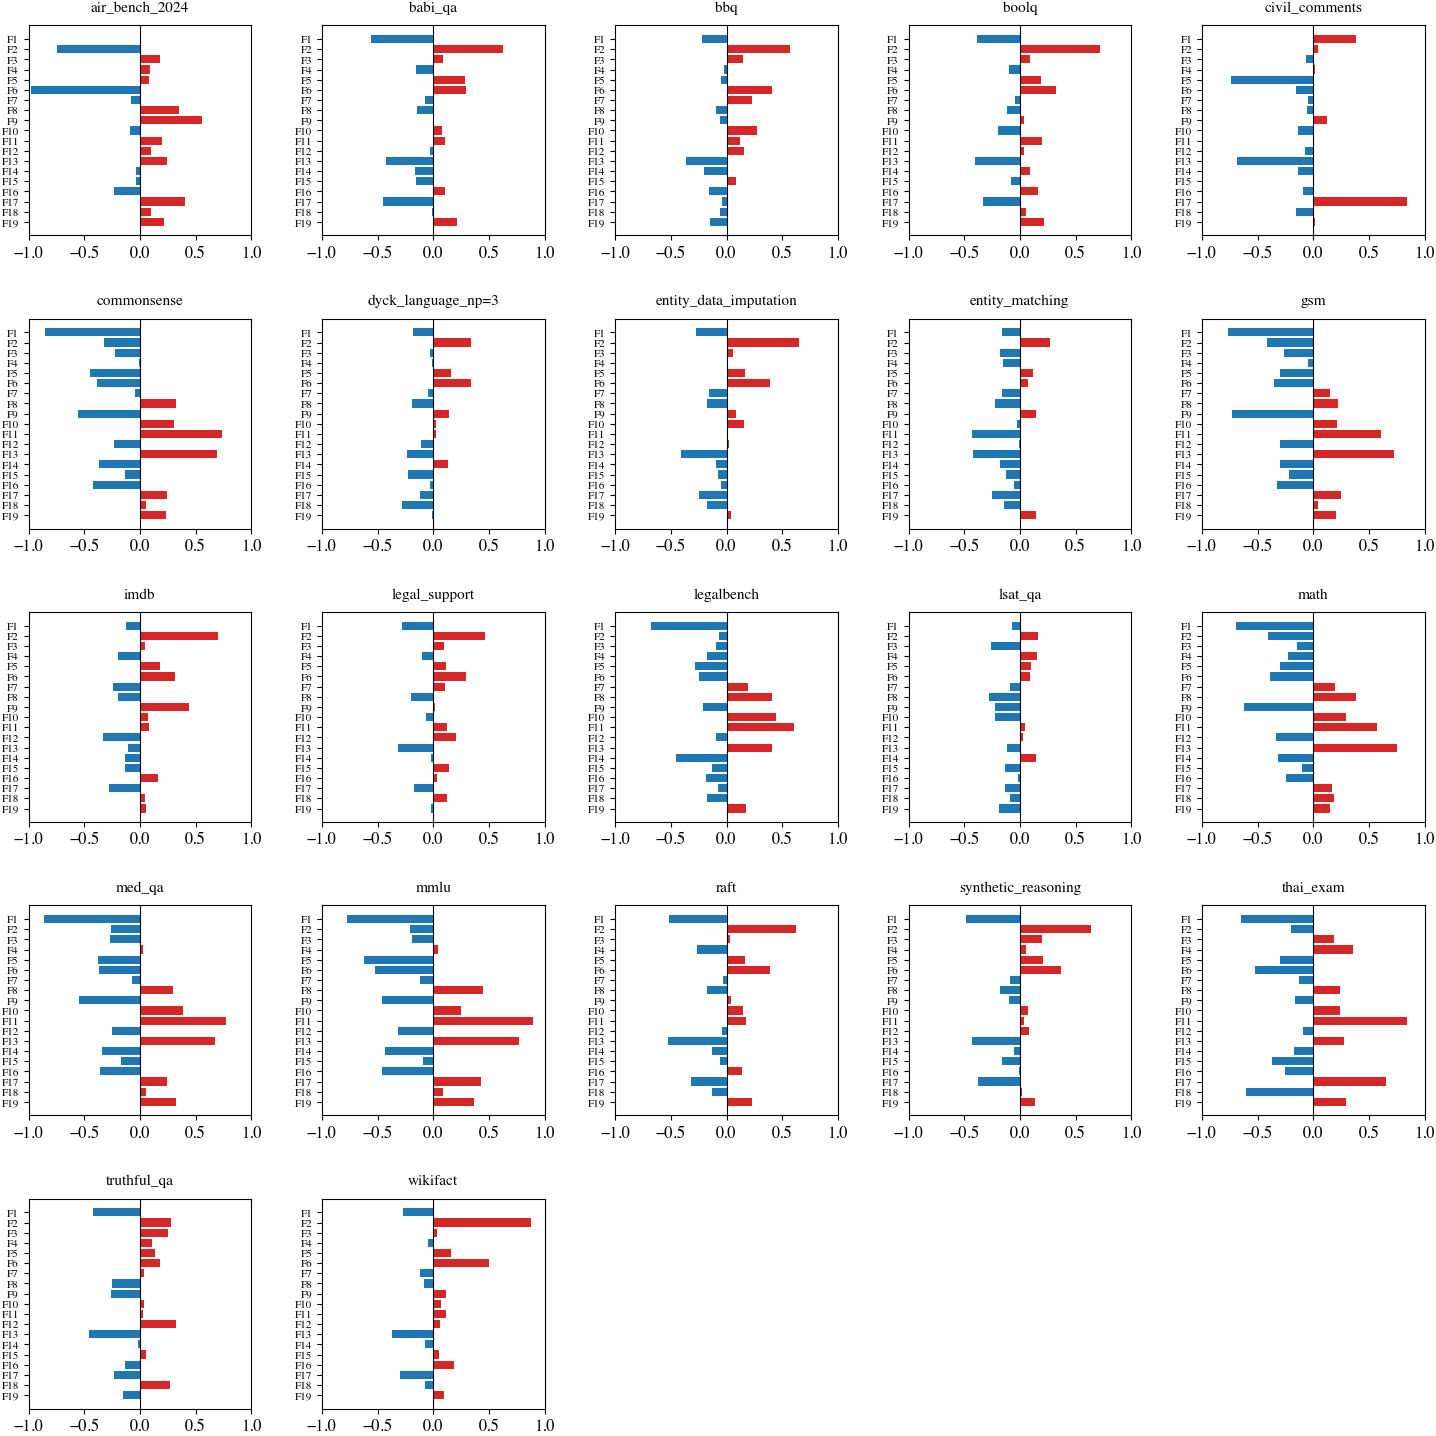

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

# ===================================================================
# == NEW: Code to Generate Bar Chart Profiles
# ===================================================================

def plot_correlation_bars(ax, values, labels, title):
    """Helper function to draw a horizontal bar chart of correlations."""
    y_pos = np.arange(len(labels))
    
    # Create colors: red for positive, blue for negative
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in values]
    
    # Plot the bars
    ax.barh(y_pos, values, color=colors)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()  # labels read top-to-bottom
    # ax.set_xlabel('Spearman Correlation', fontsize=8)
    ax.set_title(title, size=11, pad=10)
    
    # Set x-axis limits and add a vertical line at zero
    ax.set_xlim(-1.0, 1.0)
    ax.axvline(0, color='black', linewidth=0.8)


# --- Main Plotting Logic ---
factors = factor_scenario_corr.index.tolist()
scenarios = factor_scenario_corr.columns.tolist()
num_scenarios = len(scenarios)

# Create a grid of subplots (NOT polar this time)
num_cols = 5
num_rows = int(np.ceil(num_scenarios / num_cols))

fig, axes = plt.subplots(figsize=(15, num_rows * 3), nrows=num_rows, ncols=num_cols)

print("\n--- Generating Bar Chart Profiles for Each Scenario ---")

axes_flat = axes.flatten()

# Loop through each scenario and draw its chart
for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    values = factor_scenario_corr[scenario].tolist()
    plot_correlation_bars(ax, values, factors, scenario)

# Hide any unused subplots
for i in range(num_scenarios, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig("../result/factor-scenario-bar-profiles.png", dpi=300, bbox_inches='tight')
plt.show()

--- Calculating subject scores using the balanced SVD model ---
--- Standardizing the new projected factors ---
--- Saving the new factors ---
--- Generating Final Radial Heatmaps ---


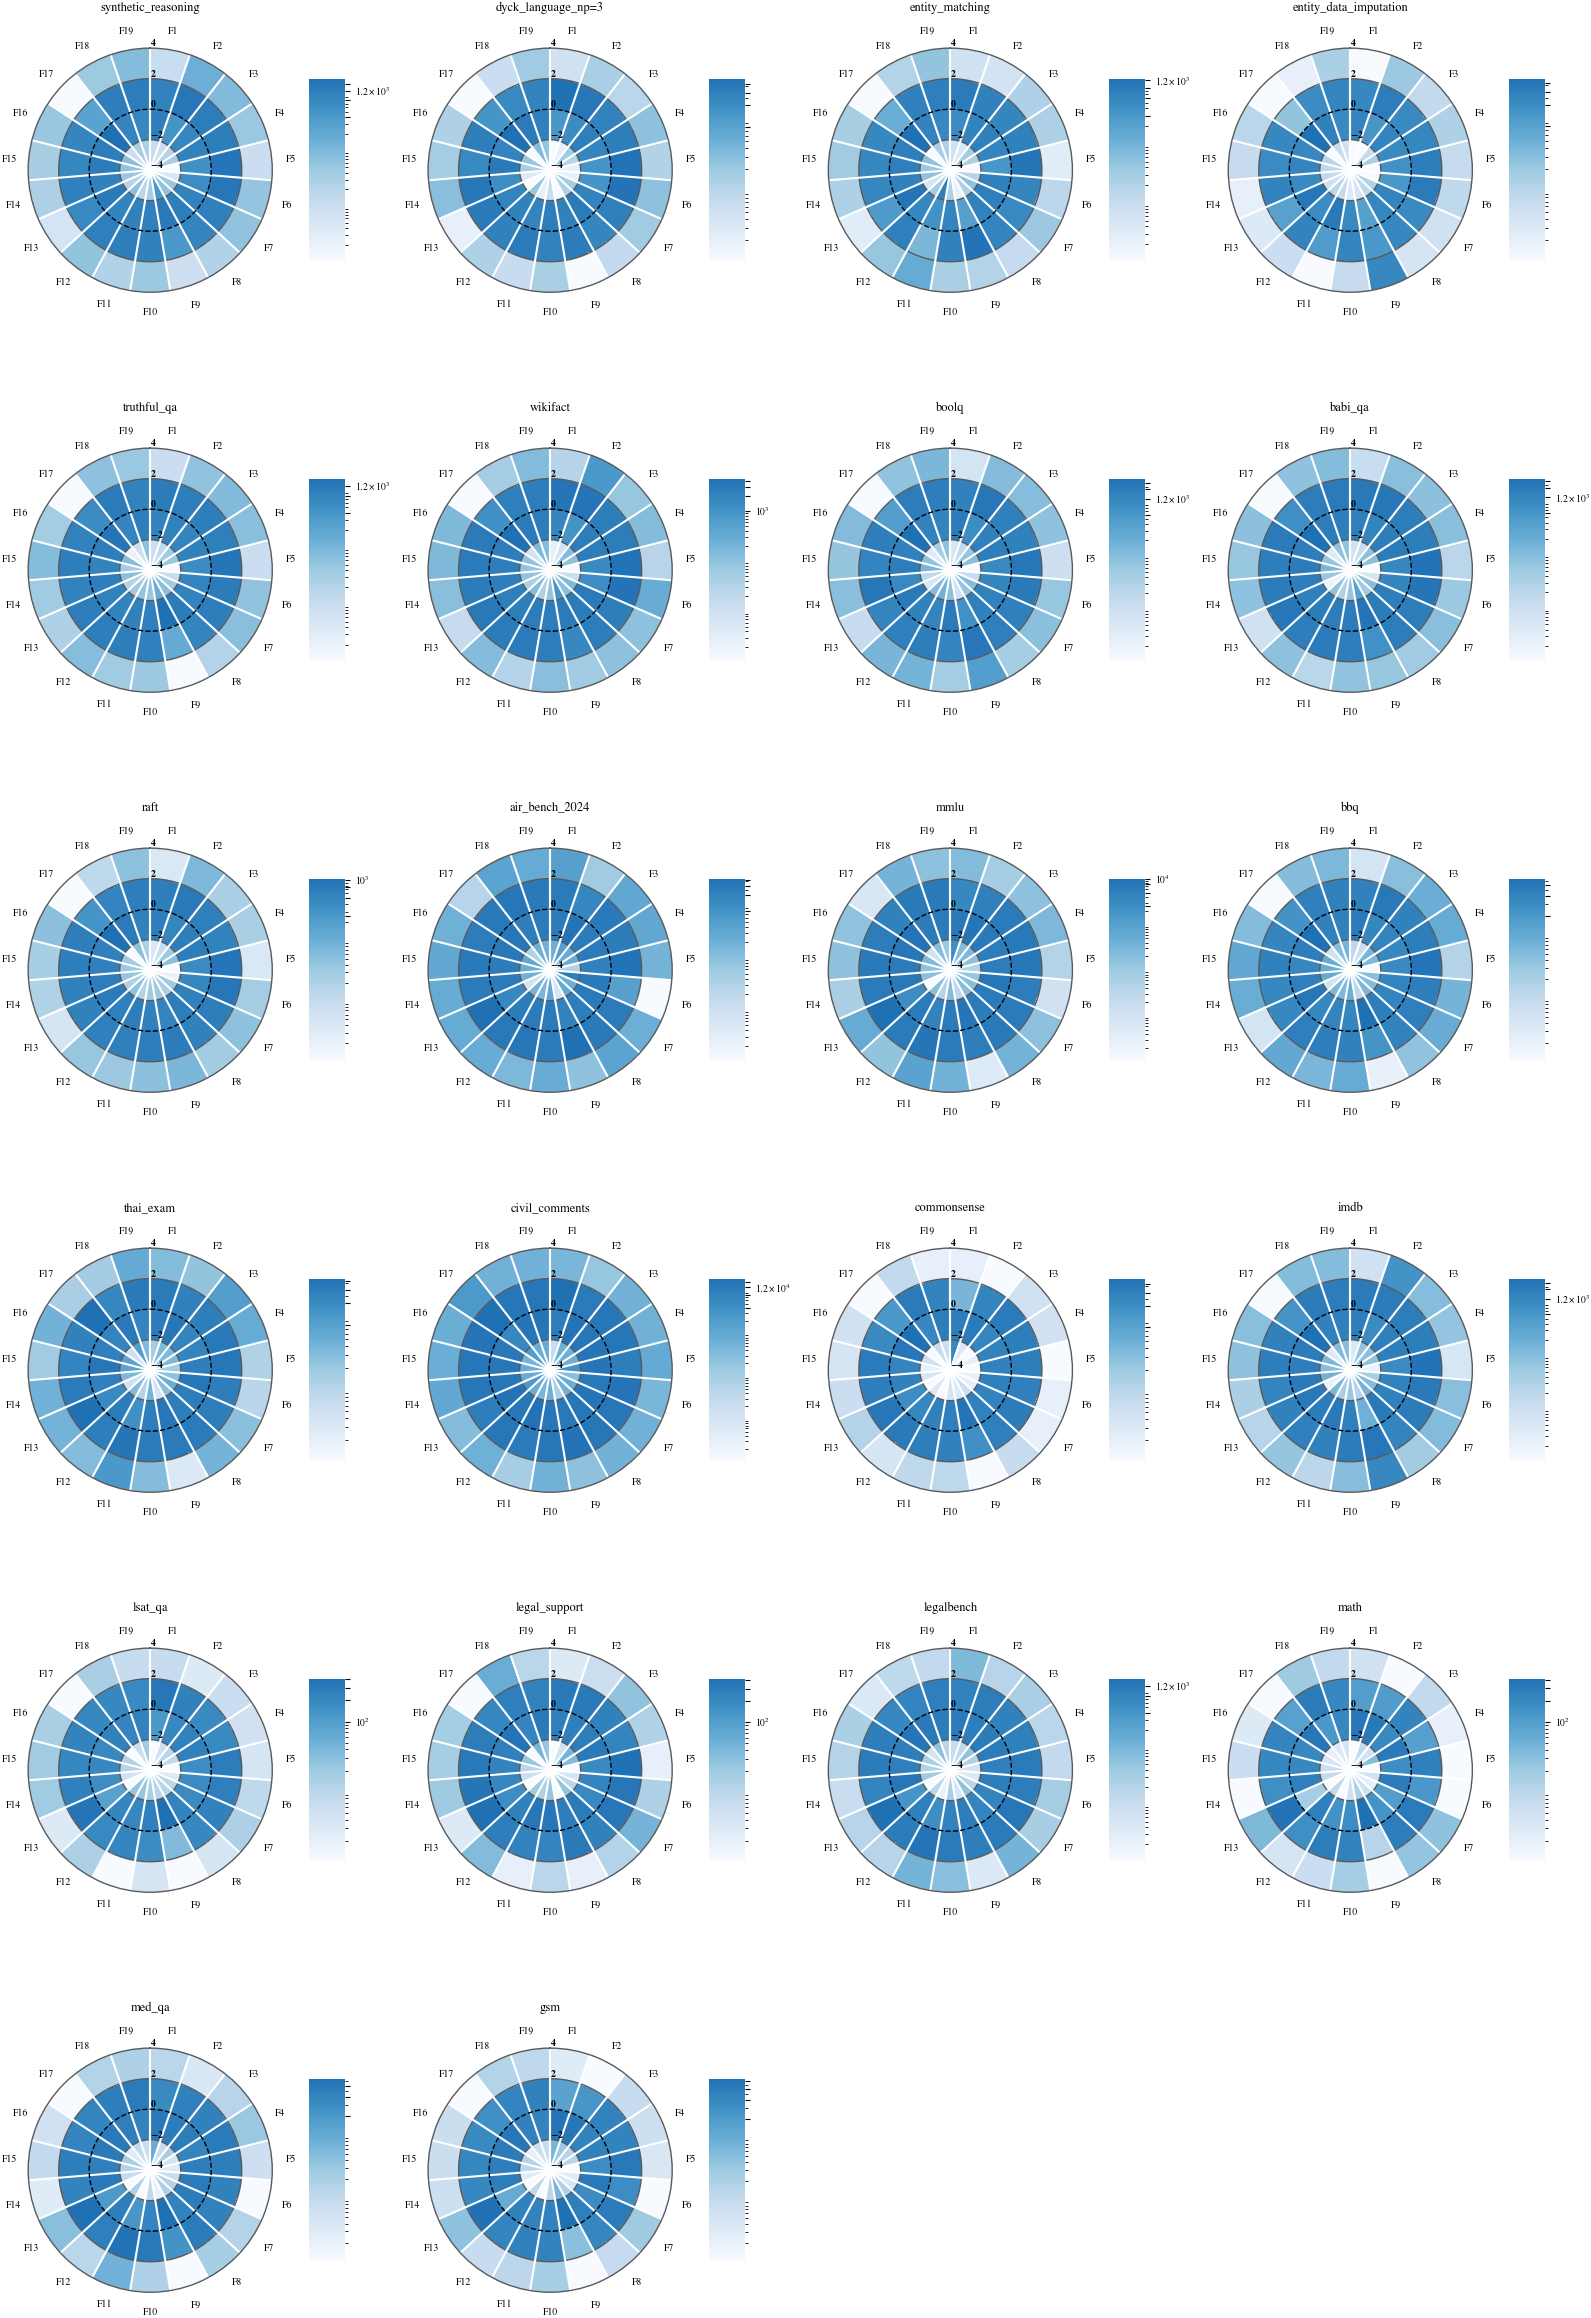

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as mticker

scenario_mapping = {
	"Factual Knowledge & Question Answering": {
		"boolq": "Requires answering yes/no questions where the answer is directly supported by a provided text passage.",
		"wikifact": "Involves fact-checking and verifying the truthfulness of statements against a knowledge source like Wikipedia.",
		"truthful_qa": "Measures a model's ability to provide true answers and avoid generating common falsehoods."
	},
	"Specialised reasoning": {
		"math": "Involves solving competition-level mathematics problems, requiring advanced numerical and symbolic reasoning.",
		"gsm": "Stands for Grade-School Math; tests multi-step quantitative reasoning on word problems.",
		"lsat_qa": "Tests analytical reasoning and logic puzzles modeled after the Law School Admission Test.",
		"legal_support": "Requires identifying a supporting legal passage for a given statement from a set of candidates.",
		"legalbench": "A broad suite of diverse benchmarks covering various legal reasoning tasks.",
		"med_qa": "Focuses on question answering in the medical domain, requiring specialized, expert-level knowledge."
	},
	"Language & Social Reasoning": {
		"civil_comments": "A dataset for toxicity detection, requiring an understanding of nuanced and potentially offensive language.",
		"imdb": "A classic sentiment analysis task for movie reviews, testing the understanding of opinionated text.",
		"bbq": "Bias Benchmark for QA; specifically designed to probe for and expose social biases in model responses.",
		"commonsense": "A general category for tasks evaluating everyday reasoning and an implicit understanding of the world.",
		"thai_exam": "Tests knowledge and language understanding based on questions from Thai academic examinations."
	},
	"Details & Logical reasoning": {
		"entity_matching": "Involves identifying if two different descriptions or records refer to the same real-world entity.",
		"entity_data_imputation": "The task of filling in missing values (imputation) for entities within a structured dataset.",
		"synthetic_reasoning": "Evaluates reasoning on procedurally generated, abstract problems to isolate logical capabilities.",
		"dyck_language_np=3": "A formal language task that tests structural understanding by checking for balanced parentheses."
	},
	"General & Multitask Evaluation": {
		"mmlu": "Massive Multitask Language Understanding; a broad benchmark covering 57 diverse academic subjects.",
		"air_bench_2024": "A comprehensive benchmark for evaluating the instruction-following capabilities of AI models across many tasks.",
		"raft": "Real-world Annotated Few-shot Tasks; a collection of diverse classification tasks with limited training examples.",
		"babi_qa": "Tests specific deductive reasoning skills using simple text-based stories and questions.",
	}
}

group_color_map = {
	"Factual Knowledge & Question Answering": "Purples",
	"Specialised reasoning": "Purples",
	"Language & Social Reasoning": "Purples",
	"Details & Logical reasoning": "Purples",
	"General & Multitask Evaluation": "Purples"
}

# 2. Create a reverse mapping from individual scenario to its group name for easy lookup.
scenario_to_group_map = {}
for group, scenarios in scenario_mapping.items():
	for scenario in scenarios.keys():
		scenario_to_group_map[scenario] = group

# --- UPDATED FUNCTION ---
def plot_scenario_svd_heatmap(scaled_scenario_factors: np.ndarray, scenario_labels: np.ndarray, unique_scenarios: list, group_color_map: dict, scenario_to_group_map: dict):
	"""
	Generates a clean, arc-shaped radial heatmap with a styled border.
	Colors each plot based on its scenario group.
	"""
	# 1. Combine data into a DataFrame
	factor_names = [f'F{i+1}' for i in range(scaled_scenario_factors.shape[1])]
	loadings_df = pd.DataFrame(scaled_scenario_factors, columns=factor_names)
	loadings_df['scenario'] = scenario_labels

	r_bins_data = np.array([-4, -2, 0, 2, 4])
	r_tick_labels = [f"$\\bf{{{b}}}$" for b in r_bins_data]  # Bold tick labels using LaTeX
	r_bins_plot = r_bins_data + 1 # We plot on a positive radius

	# 3. Setup the plot grid
	num_scenarios = len(unique_scenarios)
	num_cols = 4
	num_rows = int(np.ceil(num_scenarios / num_cols))

	fig, axes = plt.subplots(
		figsize=(num_cols * 4, num_rows * 4),
		nrows=num_rows,
		ncols=num_cols,
		subplot_kw={'projection': 'polar'},
		layout="constrained"
	)
	axes_flat = axes.flatten()
	print("--- Generating Final Radial Heatmaps ---")

	# 4. Loop through each scenario
	for i, scenario in enumerate(unique_scenarios):
		ax = axes_flat[i]
		scenario_data = loadings_df[loadings_df['scenario'] == scenario][factor_names]
		if scenario_data.empty:
			ax.set_title(f"{scenario}\n(No Data)", size=9, y=1.1)
			ax.set_yticklabels([]); ax.set_xticklabels([])
			continue
		counts_matrix = np.zeros((len(r_bins_data) - 1, len(factor_names)))
		for j, factor in enumerate(factor_names):
			counts, _ = np.histogram(scenario_data[factor].dropna(), bins=r_bins_data)
			counts_matrix[:, j] = counts

		theta_edges = np.linspace(0, 2 * np.pi, len(factor_names) + 1)
		angular_upsample_factor = 10
		upsampled_counts = np.repeat(counts_matrix, angular_upsample_factor, axis=1)
		theta_edges_fine = np.linspace(0, 2 * np.pi, (len(factor_names) * angular_upsample_factor) + 1)
		r_edges = r_bins_plot
		T, R = np.meshgrid(theta_edges_fine, r_edges)
		vmax = np.max(counts_matrix)
		norm = mcolors.Normalize(vmin=0, vmax=vmax)

		# --- NEW DYNAMIC COLORMAP LOGIC ---
		# 1. Find the group and corresponding colormap name for the current scenario
		group = scenario_to_group_map.get(scenario, "DefaultGroup")
		cmap_name = group_color_map.get(group, "Greys") # Default to 'Greys' if group is not found

		# 2. Get the original colormap from matplotlib
		original_cmap = sns.color_palette("Blues", as_cmap=True)

		# 3. Create a new colormap using the first 85% of the original's colors
		cmap = mcolors.LinearSegmentedColormap.from_list(
			f"truncated_{cmap_name}", original_cmap(np.linspace(0, 0.75, 256))
		)
		# --- END OF NEW LOGIC ---

		mesh = ax.pcolormesh(T, R, upsampled_counts + 1, cmap=cmap, norm=norm, shading='auto')

		ax.set_axisbelow(False)
		ax.xaxis.grid(False)
		ax.yaxis.grid(False)

		theta_circle = np.linspace(0, 2 * np.pi, 200)
		# This is the plot coordinate that corresponds to your original data's zero point
		zero_line_radius = 1.0

		for r_val in r_bins_plot[:-1]:
			# Check if the current radius is the one we want to style differently
			if np.isclose(r_val, zero_line_radius):
				# Apply special styling for the zero line
				ax.plot(theta_circle, np.full_like(theta_circle, r_val), color='black', lw=1, linestyle='--', zorder=5)
			else:
				# Regular styling for all other grid lines
				ax.plot(theta_circle, np.full_like(theta_circle, r_val), color='#5a5a5a', lw=1)

		# This part for the radial spokes is correct and can remain as is
		for theta in theta_edges:
			ax.plot([theta, theta], [r_bins_plot[0], r_bins_plot[-1]], color='white', lw=1.5)

		ax.spines['polar'].set_color('#5a5a5a')
		ax.spines['polar'].set_linewidth(1)
		ax.spines['polar'].set_zorder(3)

		ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
		
		theta_centers = theta_edges[:-1] + (theta_edges[1] - theta_edges[0]) / 2
		ax.set_xticks(theta_centers)
		ax.set_xticklabels(factor_names, size=7, rotation_mode='anchor', ha='center')
		ax.set_rlim(r_bins_plot[0], r_bins_plot[-1])
		ax.set_yticks(r_bins_plot)
		ax.set_yticklabels(r_tick_labels, fontsize=7)
		ax.set_rlabel_position(0)
		ax.set_title(scenario, size=9, y=1.12)
		cbar = fig.colorbar(mesh, ax=ax, shrink=0.8, aspect=5)
		cbar.ax.tick_params(labelsize=7)
		# cbar.set_label('Frequency', rotation=270, labelpad=15, fontsize=8)
		cbar.outline.set_visible(False)
		cbar.ax.yaxis.set_major_locator(mticker.MaxNLocator(5))

	for i in range(num_scenarios, len(axes_flat)):
		axes_flat[i].set_visible(False)
	plt.savefig(f"../result/factor-scenario-radial-profiles.pdf")
	plt.show()
	
# --- REVISED WORKFLOW ---

# 1. Load your full resmat and scenario labels (as you already have)
resmat = pd.read_pickle("../data/resmat.pkl")
balanced_resmat_full = resmat.columns.to_frame()
unique_scenarios = balanced_resmat_full['scenario'].unique().tolist()
scenario_labels = balanced_resmat_full['scenario'].values

# 2. Get the subject scores by transforming ONLY the balanced items from the full resmat
print("--- Calculating subject scores using the balanced SVD model ---")

all_item_factors = a_for_z_numpy

print("--- Standardizing the new projected factors ---")
scaler = StandardScaler()
scaled_factors = scaler.fit_transform(all_item_factors)

print("--- Saving the new factors ---")
np.save("../result/scaled_factors.npy", scaled_factors)

sorted_scenarios = sorted(unique_scenarios, key=lambda s: scenario_to_group_map.get(s, "zzzz_default"))

# 5. Call the plotting function with the new, correctly calculated factors
plot_scenario_svd_heatmap(
	scaled_factors,
	scenario_labels,
	sorted_scenarios,
	group_color_map,          # Pass the color map
	scenario_to_group_map     # Pass the lookup map
)

Loading and preparing data...
Normalizing data (this may take a moment)...
Data normalized successfully.
Running PCA on actual data...
Running 100 simulations in parallel...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:41<00:00,  2.42it/s]



--- Analysis Complete ---
✅ Parallel Analysis (95th percentile rule) recommends: 19 factors.
✅ Kaiser Criterion (eigenvalue > 1 rule) recommends: 182 factors.


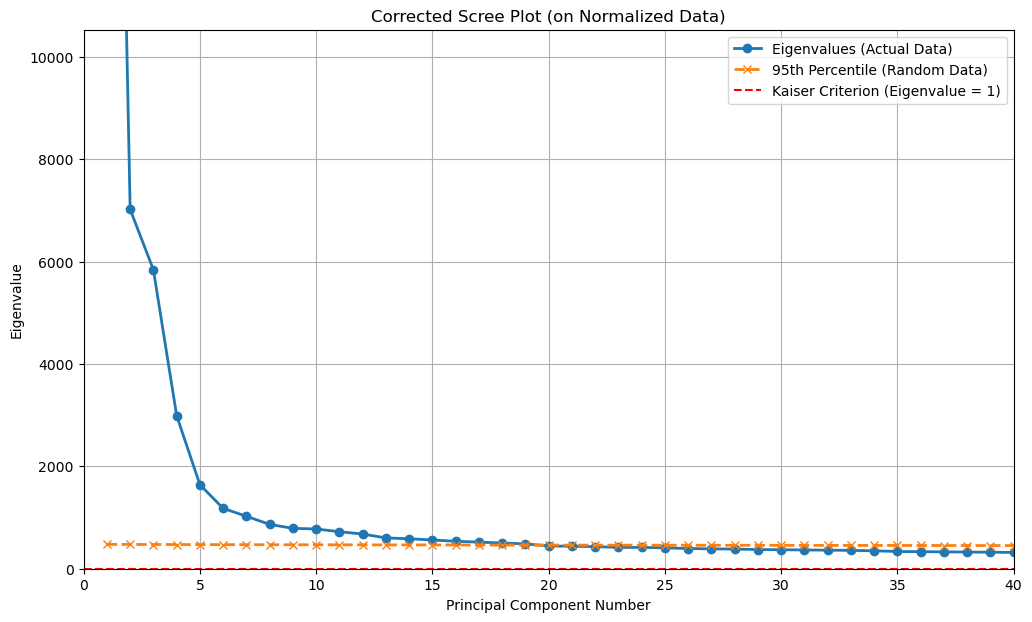

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
import os

# --- 1. Define the function for a SINGLE simulation ---
def run_single_pca_simulation(matrix_shape):
    """
    Generates a random NORMALIZED matrix, runs PCA, and returns the eigenvalues.
    """
    # Create random data
    random_matrix = np.random.normal(0, 1, matrix_shape)
    # The random data is already 'standardized' by definition (mean=0, std=1)
    
    n_components = matrix_shape[0] - 1
    # Note: No need for 'randomized' solver on this size of random data, 
    # the standard 'auto' is efficient.
    pca_random = PCA(n_components=n_components)
    pca_random.fit(random_matrix)
    
    # Return the raw eigenvalues (explained_variance_)
    return pca_random.explained_variance_

# ===================================================================
# --- Main Script ---
# ===================================================================

# --- 2. Load and Prepare Data ---
print("Loading and preparing data...")
shapeMatrix = pd.read_pickle("../data/resmat.pkl")
shapeMatrix.fillna(0, inplace=True)

# --- 3. NORMALIZE THE DATA ---
# This is the critical step. We standardize the data to have a mean of 0 and a variance of 1.
# This is equivalent to running PCA on the correlation matrix.
print("Normalizing data (this may take a moment)...")
scaler = StandardScaler()
normalized_shapeMatrix = scaler.fit_transform(shapeMatrix)
print("Data normalized successfully.")

# --- 4. Run PCA on your ACTUAL NORMALIZED data ---
print("Running PCA on actual data...")
n_components = normalized_shapeMatrix.shape[0] - 1
pca = PCA(n_components=n_components)
pca.fit(normalized_shapeMatrix)
# Get the raw eigenvalues for the real data
real_eigenvalues = pca.explained_variance_

# --- 5. Run simulations IN PARALLEL on all CPU cores ---
n_simulations = 1000
print(f"Running {n_simulations} simulations in parallel...")
results = Parallel(n_jobs=-1)(
    delayed(run_single_pca_simulation)(normalized_shapeMatrix.shape) for i in tqdm(range(n_simulations))
)

# --- 6. Aggregate results and find the number of factors ---
all_random_eigenvalues = np.array(results)
percentile_eigenvalues = np.percentile(all_random_eigenvalues, 95, axis=0)

# Find the number of factors from Parallel Analysis
n_factors_parallel = sum(real_eigenvalues > percentile_eigenvalues)

# Find the number of factors from the (now valid) Kaiser Criterion
n_factors_kaiser = sum(real_eigenvalues > 1)

print("\n--- Analysis Complete ---")
print(f"✅ Parallel Analysis (95th percentile rule) recommends: {n_factors_parallel} factors.")
print(f"✅ Kaiser Criterion (eigenvalue > 1 rule) recommends: {n_factors_kaiser} factors.")


# --- 7. Generate the Final Scree Plot ---
plt.figure(figsize=(12, 7))
x_values = range(1, n_components + 1)

plt.plot(x_values, real_eigenvalues, 'o-', linewidth=2, label='Eigenvalues (Actual Data)')
plt.plot(x_values, percentile_eigenvalues, 'x--', linewidth=2, label='95th Percentile (Random Data)')
plt.axhline(y=1, color='r', linestyle='--')

plt.title('Corrected Scree Plot (on Normalized Data)')
plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue')
plt.grid()
plt.legend()
# Focus on the most important part of the plot
plt.xlim(0, 40) 
plt.ylim(0, max(real_eigenvalues[1:])*1.5) # Zoom in, ignoring the first factor for scale

# Save the plot
output_dir = "../results"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, "corrected_scree_plot.png"))
plt.show()

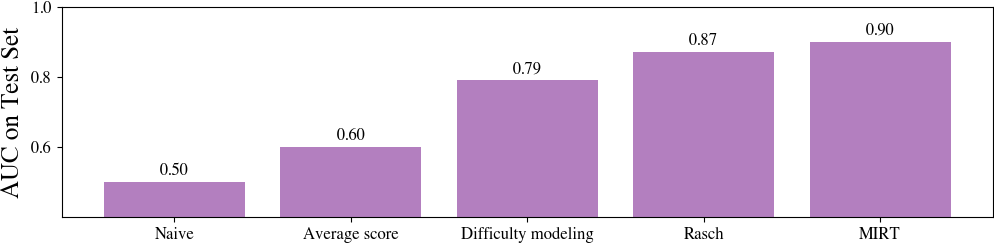

In [22]:
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)
values = [0.5, 0.6, 0.79, 0.87, 0.9]
labels = ['Naive', 'Average score', 'Difficulty modeling', 'Rasch', 'MIRT']

fig, ax = plt.subplots(figsize=(10, 2.5))
bars = ax.bar(labels, values, color='#b37fbf')

# ax.set_xlabel(r'Response Model', fontsize=15)
ax.set_ylabel(r'AUC on Test Set', fontsize=18)
ax.set_ylim(0.4, 1.0)
ax.set_yticks([i/5 for i in range(3, 6)])
plt.tick_params(axis="both", labelsize=12)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.2f}', 
            ha='center', va='bottom', fontsize=12)

plt.savefig("../result/test_auc_grow.pdf", bbox_inches="tight")

plt.show()

In [ ]:
from sklearn.manifold import TSNE

# ===================================================================
# == Step 2: Extract the Scenario Representations
# ===================================================================
# The matrix `model_final.components_` has a shape of (k, n_scenarios).
# We need to transpose it to get (n_scenarios, k) for t-SNE.
scenario_factors = a_for_z_numpy
print(f"Extracted scenario factors with shape: {scenario_factors.shape}")

# ===================================================================
# == Step 3: Run t-SNE to Reduce to 2 Dimensions
# ===================================================================
print("\nRunning t-SNE to reduce dimensions for visualization...")
# Note: t-SNE can be slow on large datasets. This might take a few minutes.
tsne = TSNE(n_components=2, perplexity=300, random_state=42, n_jobs=-1)
scenario_2d = tsne.fit_transform(scenario_factors)
np.save("../result/scenario_2d.npy", scenario_2d)
np.save("../result/scenario_factors.npy", scenario_factors)
print(f"t-SNE complete. New data shape: {scenario_2d.shape}")
print("Saved to ../result/scenario_2d.npy and ../result/scenario_factors.npy")

Extracted scenario factors with shape: (78712, 19)

Running t-SNE to reduce dimensions for visualization...


KeyboardInterrupt: 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_79462/2450131891.py:30: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_79462/2450131891.py:46: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.




Generating plot...


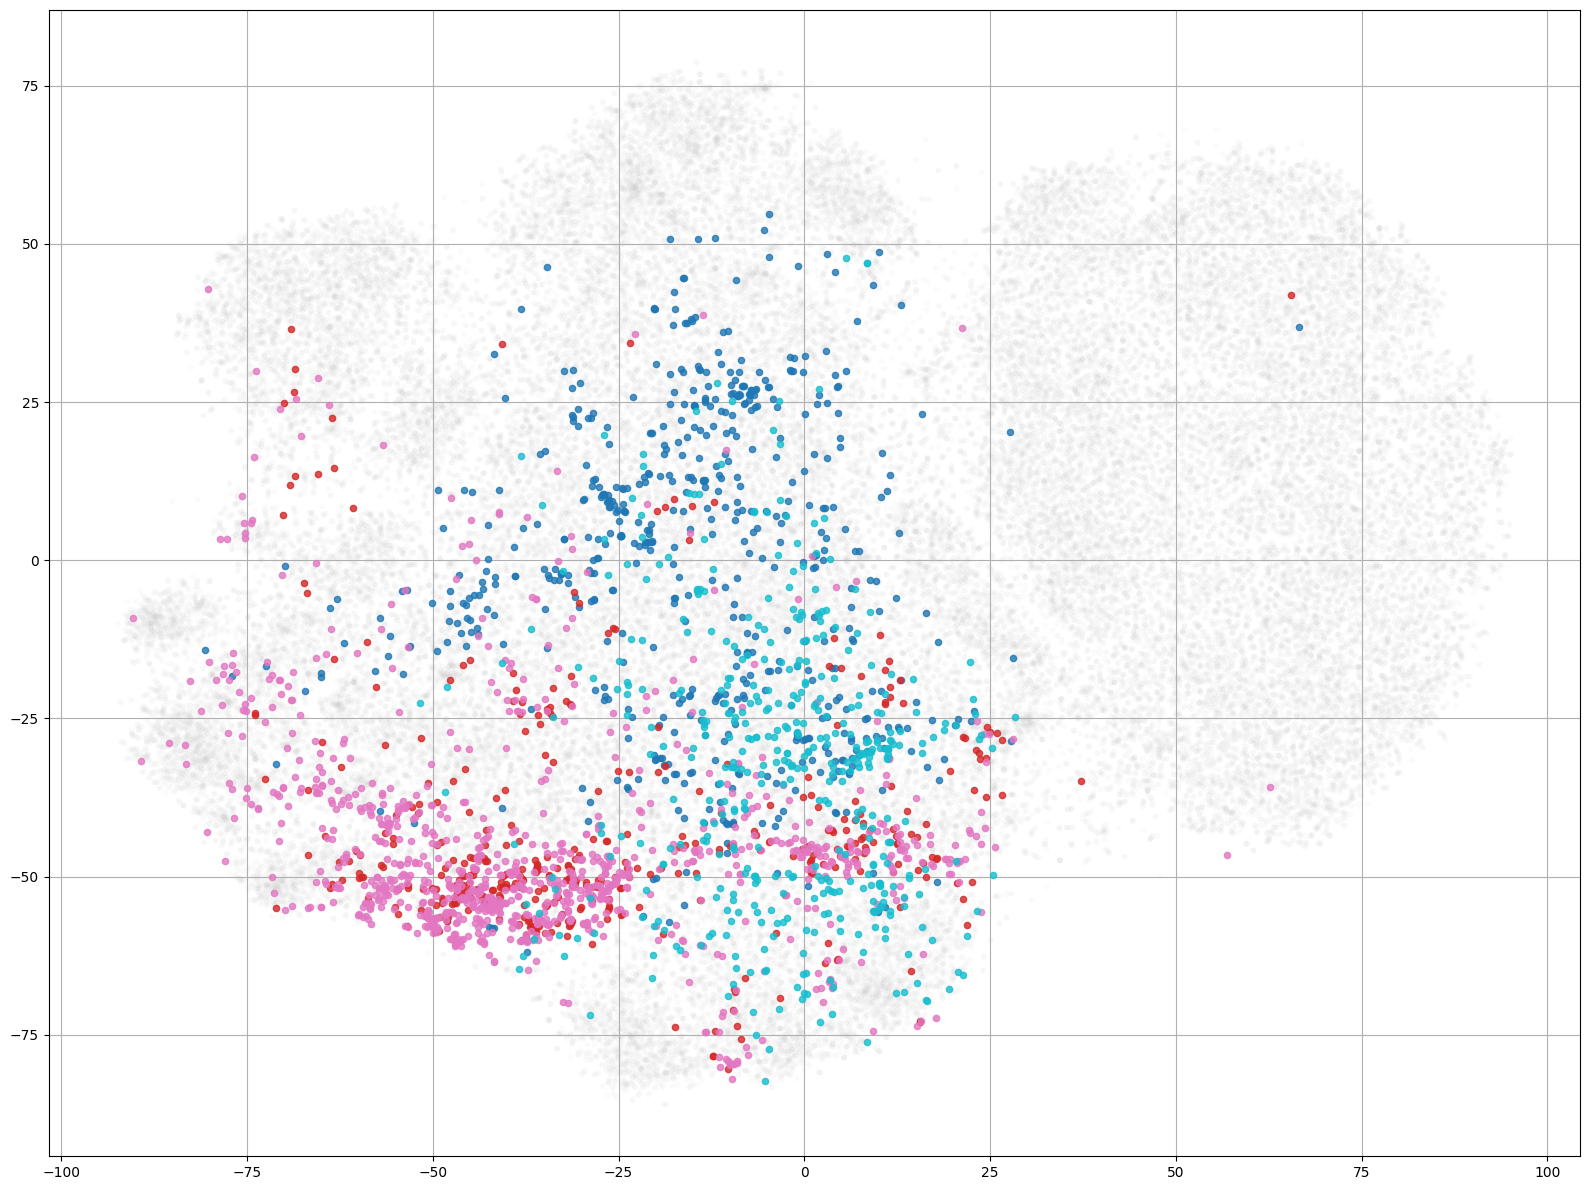

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# Assuming scenarios_2d and other variables are loaded as in your original script
scenario_2d = np.load("../result/scenario_2d.npy")
scenario_factors = np.load("../result/scenario_factors.npy")

# ===================================================================
# == Step 4: Create an Interpretable Visualization
# ===================================================================
# To color the plot, we need to know which scenario each of the 78,712 columns belongs to.
# Let's load the scenario names and the mapping you created in your notebook.

# Load the list of unique scenario names
balanced_resmat = pd.read_pickle("../data/resmat.pkl").columns.to_frame()
unique_scenarios = balanced_resmat['scenario'].unique().tolist()

# Get the scenario label for each of the 78,712 columns
scenario_labels = balanced_resmat['scenario'].values

# --- MODIFICATION START ---

# Define the specific labels you want to color
labels_to_color = ['legal_support', 'math', 'gsm', 'lsat_qa']
default_color = 'lightgrey' # Color for all other points

# Create a color map only for the specified labels
colors = cm.get_cmap('tab10', len(labels_to_color)) # Using 'tab10' for distinct colors
color_map = {label: colors(i) for i, label in enumerate(labels_to_color)}

print("\nGenerating plot...")
plt.figure(figsize=(16, 12))

# Plot non-colored points first (lower z-order)
non_colored_mask = ~np.isin(scenario_labels, labels_to_color)
if np.any(non_colored_mask):
    plt.scatter(scenario_2d[non_colored_mask, 0], scenario_2d[non_colored_mask, 1], 
                c=default_color, alpha=0.05, s=10, zorder=1)

# Plot colored points second (higher z-order) 
for label in labels_to_color:
    colored_mask = scenario_labels == label
    if np.any(colored_mask):
        plt.scatter(scenario_2d[colored_mask, 0], scenario_2d[colored_mask, 1], 
                    c=color_map[label], alpha=0.8, s=20, zorder=2, label=label)

# Create legend handles for all unique scenarios
all_unique_labels = np.unique(scenario_labels)
handles = []

# Add handles for colored scenarios first
for scen in labels_to_color:
    if scen in all_unique_labels:
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=scen,
                                markerfacecolor=color_map[scen], markersize=10))

# Add handles for non-colored scenarios
for scen in all_unique_labels:
    if scen not in labels_to_color:
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=scen,
                                markerfacecolor=default_color, markersize=8))

# plt.legend(handles=handles, title='Scenarios', bbox_to_anchor=(1.05, 1), loc='upper left', 
#            fontsize=8, title_fontsize=10)

# --- MODIFICATION END ---

# plt.title('t-SNE Visualization of Test Scenarios')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
plt.savefig(f"../result/factor-scenario-tsne-highlighted.pdf", bbox_inches='tight')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# ===================================================================
# == Step 1: Generate 3D t-SNE Embeddings
# ===================================================================
print("Loading scenario factors...")
scenario_factors = a_for_z_numpy
print(f"Scenario factors shape: {scenario_factors.shape}")

print("\nRunning 3D t-SNE to reduce dimensions for visualization...")
# Note: 3D t-SNE takes longer than 2D. This might take several minutes.
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42, n_jobs=-1)
scenario_3d = tsne_3d.fit_transform(scenario_factors)
np.save("../result/scenario_3d.npy", scenario_3d)
print(f"3D t-SNE complete. New data shape: {scenario_3d.shape}")
print("Saved to ../result/scenario_3d.npy")

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_79339/1664673950.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20b', len(labels_to_color)) # Using 'tab10' for distinct colors
/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_79339/1664673950.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(scenario_2d[colored_mask, 0], scenario_2d[colored_mask, 1],



Generating plot...


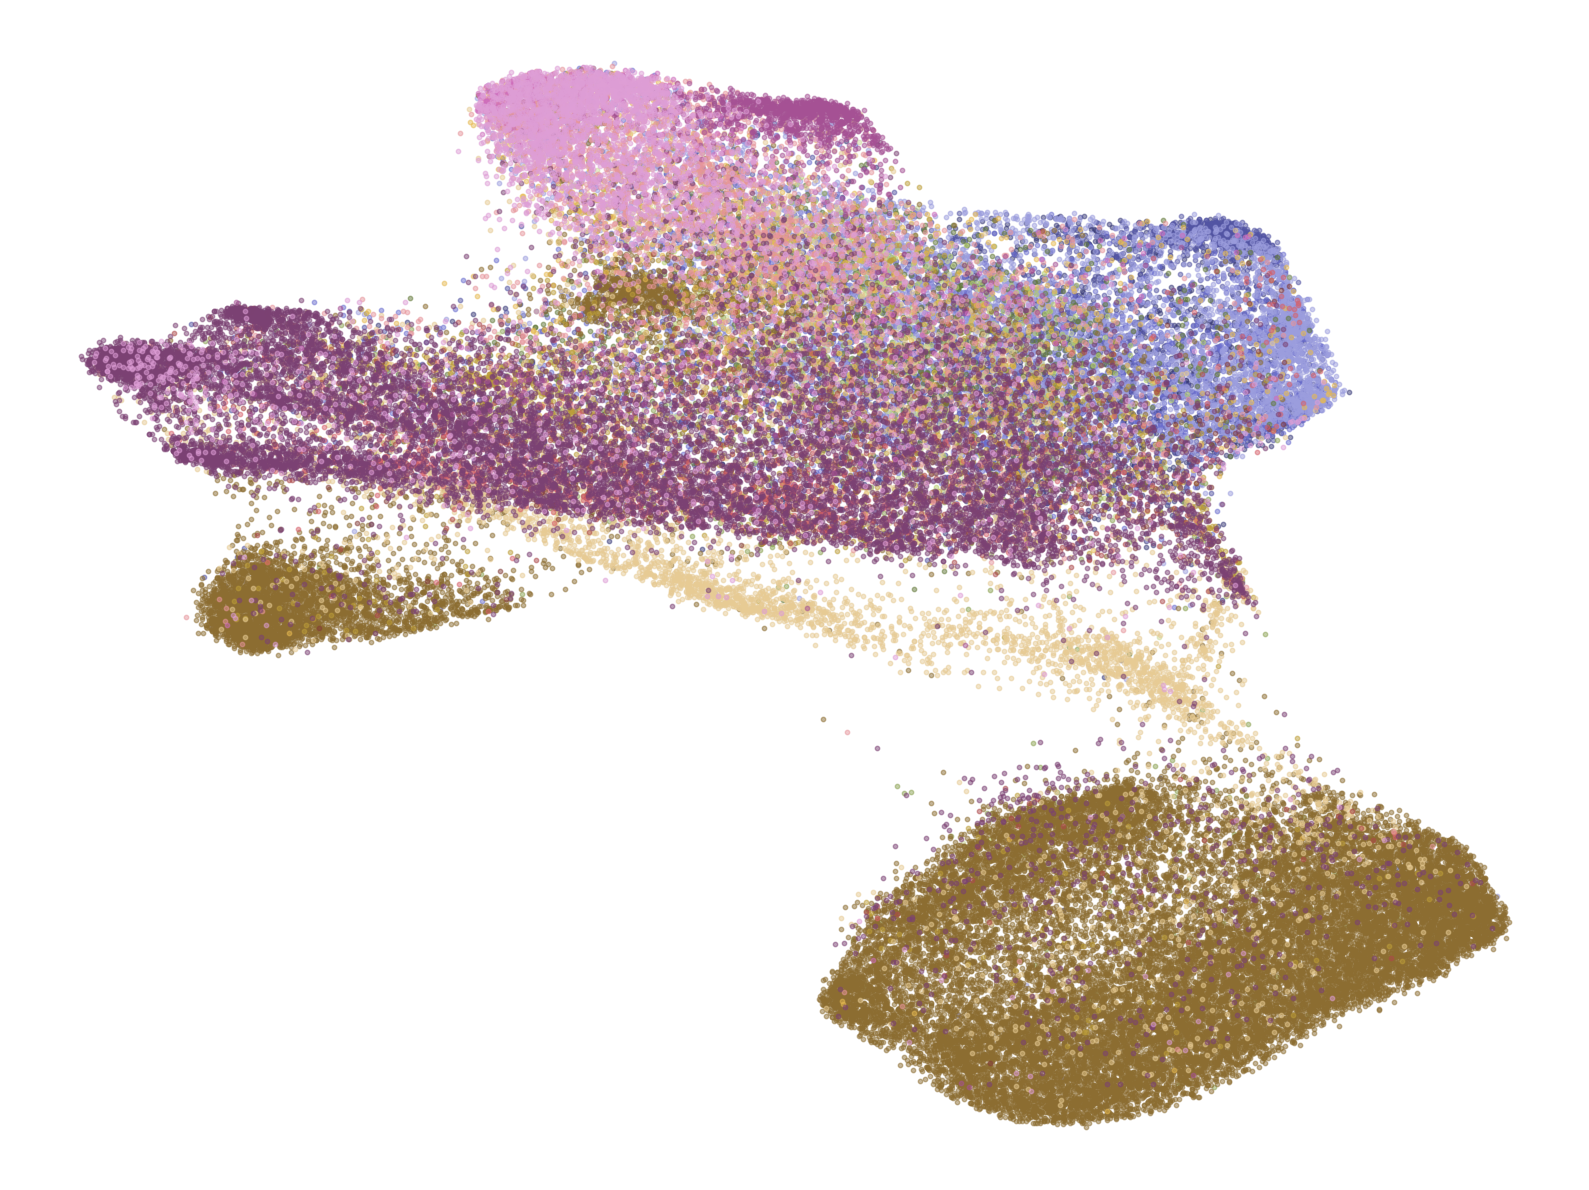

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# Assuming scenarios_2d and other variables are loaded as in your original script
scenario_2d = np.load("../result/umap_2d.npy")
scenario_factors = np.load("../result/scenario_factors.npy")

# ===================================================================
# == Step 4: Create an Interpretable Visualization
# ===================================================================
# To color the plot, we need to know which scenario each of the 78,712 columns belongs to.
# Let's load the scenario names and the mapping you created in your notebook.

# Load the list of unique scenario names
balanced_resmat = pd.read_pickle("../data/resmat.pkl").columns.to_frame()
unique_scenarios = balanced_resmat['scenario'].unique().tolist()

# Get the scenario label for each of the 78,712 columns
scenario_labels = balanced_resmat['scenario'].values

# --- MODIFICATION START ---

# Define the specific labels you want to color
labels_to_color = unique_scenarios
default_color = 'lightgrey' # Color for all other points

# Create a color map only for the specified labels
colors = cm.get_cmap('tab20b', len(labels_to_color)) # Using 'tab10' for distinct colors
color_map = {label: colors(i) for i, label in enumerate(labels_to_color)}

print("\nGenerating plot...")
plt.figure(figsize=(16, 12))

# Plot non-colored points first (lower z-order)
non_colored_mask = ~np.isin(scenario_labels, labels_to_color)
if np.any(non_colored_mask):
    plt.scatter(scenario_2d[non_colored_mask, 0], scenario_2d[non_colored_mask, 1], 
                c=default_color, alpha=0.05, s=10, zorder=1)

# Plot colored points second (higher z-order) 
for label in labels_to_color:
    colored_mask = scenario_labels == label
    if np.any(colored_mask):
        plt.scatter(scenario_2d[colored_mask, 0], scenario_2d[colored_mask, 1], 
                    c=color_map[label], alpha=0.5, s=10, zorder=2, label=label)

# Create legend handles for all unique scenarios
all_unique_labels = np.unique(scenario_labels)
handles = []

# Add handles for colored scenarios first
for scen in labels_to_color:
    if scen in all_unique_labels:
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=scen,
                                markerfacecolor=color_map[scen], markersize=10))

# Add handles for non-colored scenarios
for scen in all_unique_labels:
    if scen not in labels_to_color:
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=scen,
                                markerfacecolor=default_color, markersize=8))

# plt.legend(handles=handles, title='Scenarios', bbox_to_anchor=(1.05, 1), loc='upper left', 
#            fontsize=8, title_fontsize=10)

# --- MODIFICATION END ---

# plt.title('t-SNE Visualization of Test Scenarios')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
plt.savefig(f"../result/factor-scenario-umap.pdf")
plt.grid(False)
plt.axis('off') 
plt.tight_layout()
plt.show()